In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import datetime
#Smart file locator
if os.path.exists("data/data/SPY_15m_data.csv"):
    target_file = "data/data/SPY_15m_data.csv"
else:
    target_file = "data/SPY_15m_data.csv"

#Load the data 
data = pd.read_csv(target_file, index_col=0, parse_dates=True)

#Rebuild the core baselines for comparison
data['market_return'] = data['close'].pct_change()
data['buy_and_hold'] = (1 + data['market_return']).cumprod()

#Clean up the first empty row
data.dropna(inplace=True)

print(f"Environment ready! Data loaded and baselines calculated. Total rows: {len(data)}")

Environment ready! Data loaded and baselines calculated. Total rows: 1559


Scanning dataset for Fair Value Gaps and tracking mitigations. Please wait...

--- FVG LEVEL PERFORMANCE ---
        Win Rate  Total Trades
level                         
open   72.992701           137
mid    51.612903            62
close  48.214286            56

--- FVG TIMING PERFORMANCE ---
                             Win Rate  Total Trades
session                                            
1_AM Session (9:30-11:00)   59.589041           146
2_Lunch (11:00-13:30)       59.420290            69
3_PM Session (13:30-16:00)  77.500000            40


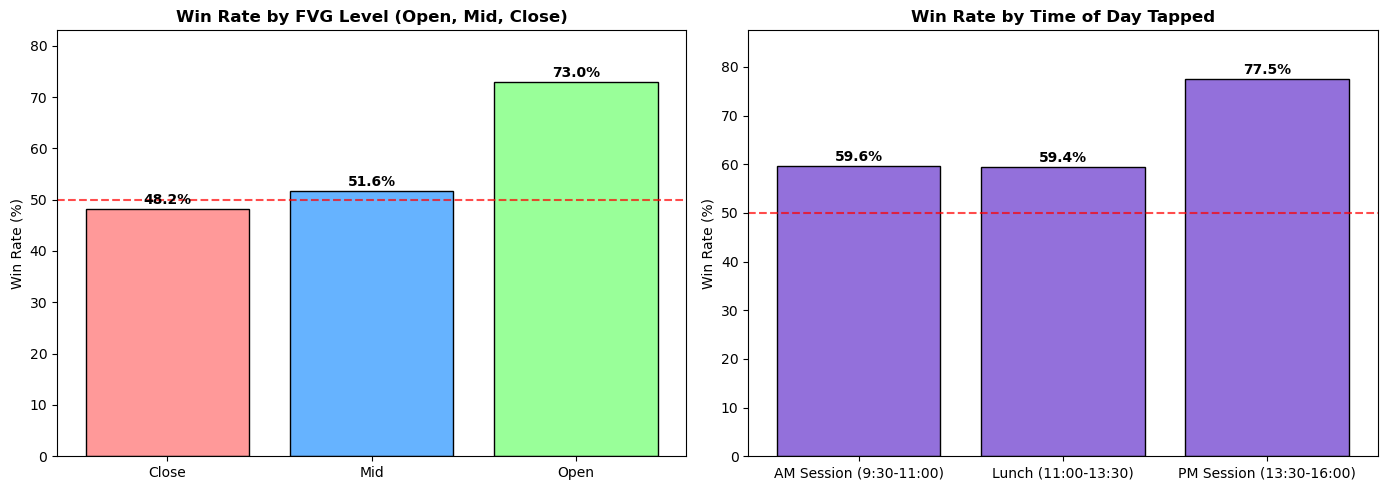

In [3]:
# --- 1. PREPARE DATA ARRAYS FOR SPEED ---
data['date'] = data.index.date
data['time'] = data.index.time
data['datetime'] = data.index

highs = data['high'].values
lows = data['low'].values
closes = data['close'].values
times = data['time'].values
dates = data['date'].values

# Standardized Risk/Reward for testing structural respect
take_profit_pct = 0.005
stop_loss_pct = 0.005

active_fvgs = []
fvg_results = []

print("Scanning dataset for Fair Value Gaps and tracking mitigations. Please wait...")

# --- 2. THE FVG SCANNER & TRACKER LOOP ---
for i in range(2, len(data)):
    current_date = dates[i]
    current_time = times[i]
    
    # Clear active FVGs overnight (Focusing on Intraday SMC setups)
    if current_date != dates[i-1]:
        active_fvgs = []
        
    # A. IDENTIFY NEW FVGs (Candle 1 vs Candle 3)
    c1_high = highs[i-2]
    c1_low = lows[i-2]
    c3_high = highs[i]
    c3_low = lows[i]
    
    # Bullish FVG (C1 High < C3 Low)
    if c1_high < c3_low:
        gap_open = c3_low
        gap_close = c1_high
        gap_mid = (gap_open + gap_close) / 2
        active_fvgs.append({
            'type': 'bull', 'open': gap_open, 'mid': gap_mid, 'close': gap_close,
            'time_formed': current_time, 'open_hit': False, 'mid_hit': False, 'close_hit': False
        })
        
    # Bearish FVG (C1 Low > C3 High)
    elif c1_low > c3_high:
        gap_open = c3_high
        gap_close = c1_low
        gap_mid = (gap_open + gap_close) / 2
        active_fvgs.append({
            'type': 'bear', 'open': gap_open, 'mid': gap_mid, 'close': gap_close,
            'time_formed': current_time, 'open_hit': False, 'mid_hit': False, 'close_hit': False
        })

    # B. CHECK FOR MITIGATION (TAPS) ON ACTIVE FVGs
    current_high = highs[i]
    current_low = lows[i]
    
    for fvg in active_fvgs:
        # Check Bullish FVGs (Price dipping down into the gap)
        if fvg['type'] == 'bull':
            levels_to_check = [('open', fvg['open']), ('mid', fvg['mid']), ('close', fvg['close'])]
            for level_name, level_price in levels_to_check:
                if not fvg[f'{level_name}_hit'] and current_low <= level_price:
                    fvg[f'{level_name}_hit'] = True
                    # Forward scan to see if this level held for a 0.5% reversal or failed
                    for j in range(i, len(data)):
                        if dates[j] != current_date: # End of day
                            break
                        if highs[j] >= level_price * (1 + take_profit_pct):
                            fvg_results.append({'level': level_name, 'time_hit': current_time, 'win': 1})
                            break
                        elif lows[j] <= level_price * (1 - stop_loss_pct):
                            fvg_results.append({'level': level_name, 'time_hit': current_time, 'win': 0})
                            break

        # Check Bearish FVGs (Price spiking up into the gap)
        elif fvg['type'] == 'bear':
            levels_to_check = [('open', fvg['open']), ('mid', fvg['mid']), ('close', fvg['close'])]
            for level_name, level_price in levels_to_check:
                if not fvg[f'{level_name}_hit'] and current_high >= level_price:
                    fvg[f'{level_name}_hit'] = True
                    # Forward scan to see if this level held for a 0.5% reversal or failed
                    for j in range(i, len(data)):
                        if dates[j] != current_date: # End of day
                            break
                        if lows[j] <= level_price * (1 - take_profit_pct):
                            fvg_results.append({'level': level_name, 'time_hit': current_time, 'win': 1})
                            break
                        elif highs[j] >= level_price * (1 + stop_loss_pct):
                            fvg_results.append({'level': level_name, 'time_hit': current_time, 'win': 0})
                            break

# --- 3. ANALYZE AND VISUALIZE THE RESULTS ---
results_df = pd.DataFrame(fvg_results)

if results_df.empty:
    print("No FVG mitigations met the 0.5% target/stop criteria in this dataset.")
else:
    # Categorize by Time of Day
    def categorize_time(t):
        if t < datetime.time(11, 0): return '1_AM Session (9:30-11:00)'
        elif t < datetime.time(13, 30): return '2_Lunch (11:00-13:30)'
        else: return '3_PM Session (13:30-16:00)'

    results_df['session'] = results_df['time_hit'].apply(categorize_time)

    # Calculate Win Rates by Level
    level_stats = results_df.groupby('level')['win'].agg(['mean', 'count']).rename(columns={'mean': 'Win Rate', 'count': 'Total Trades'})
    level_stats['Win Rate'] *= 100

    # Calculate Win Rates by Session
    session_stats = results_df.groupby('session')['win'].agg(['mean', 'count']).rename(columns={'mean': 'Win Rate', 'count': 'Total Trades'})
    session_stats['Win Rate'] *= 100

    print("\n--- FVG LEVEL PERFORMANCE ---")
    print(level_stats.sort_values('Win Rate', ascending=False))

    print("\n--- FVG TIMING PERFORMANCE ---")
    print(session_stats)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Levels
    bars1 = axes[0].bar(level_stats.index.str.title(), level_stats['Win Rate'], color=['#ff9999','#66b3ff','#99ff99'], edgecolor='black')
    axes[0].set_title('Win Rate by FVG Level (Open, Mid, Close)', fontweight='bold')
    axes[0].set_ylabel('Win Rate (%)')
    axes[0].set_ylim(0, max(level_stats['Win Rate']) + 10)
    axes[0].axhline(50, color='red', linestyle='--', alpha=0.7)
    for bar in bars1:
        yval = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', fontweight='bold')

    # Plot 2: Sessions
    bars2 = axes[1].bar([s.split('_')[1] for s in session_stats.index], session_stats['Win Rate'], color='mediumpurple', edgecolor='black')
    axes[1].set_title('Win Rate by Time of Day Tapped', fontweight='bold')
    axes[1].set_ylabel('Win Rate (%)')
    axes[1].set_ylim(0, max(session_stats['Win Rate']) + 10)
    axes[1].axhline(50, color='red', linestyle='--', alpha=0.7)
    for bar in bars2:
        yval = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [4]:
import pandas as pd
import numpy as np

# --- 1. PREPARE ARRAYS ---
dates = data.index.date
highs = data['high'].values
lows = data['low'].values

all_fvgs = []   # Master list to store historical record of all FVGs
active_fvgs = [] # Temporary list for intraday tracking

print("Scanning for FVG mitigation rates...")

# --- 2. FVG CREATION & MITIGATION LOOP ---
for i in range(2, len(data)):
    current_date = dates[i]
    
    # Clear active FVGs overnight (we only care about intraday fills for this test)
    if current_date != dates[i-1]:
        active_fvgs = []
        
    # A. IDENTIFY NEW FVGs (Candle 1 vs Candle 3)
    c1_high = highs[i-2]
    c1_low = lows[i-2]
    c3_high = highs[i]
    c3_low = lows[i]
    
    # Bullish FVG
    if c1_high < c3_low:
        new_fvg = {
            'type': 'bull', 
            'open': c3_low,   # The top of the gap (first touch)
            'close': c1_high, # The bottom of the gap (full fill)
            'tapped': False, 
            'filled': False
        }
        active_fvgs.append(new_fvg)
        all_fvgs.append(new_fvg)
        
    # Bearish FVG
    elif c1_low > c3_high:
        new_fvg = {
            'type': 'bear', 
            'open': c3_high,  # The bottom of the gap (first touch)
            'close': c1_low,  # The top of the gap (full fill)
            'tapped': False, 
            'filled': False
        }
        active_fvgs.append(new_fvg)
        all_fvgs.append(new_fvg)

    # B. CHECK FOR MITIGATION (TAPS & FILLS)
    current_high = highs[i]
    current_low = lows[i]
    
    for fvg in active_fvgs:
        if fvg['type'] == 'bull':
            # Price dips down into the gap
            if current_low <= fvg['open']:
                fvg['tapped'] = True
            if current_low <= fvg['close']:
                fvg['filled'] = True
                
        elif fvg['type'] == 'bear':
            # Price spikes up into the gap
            if current_high >= fvg['open']:
                fvg['tapped'] = True
            if current_high >= fvg['close']:
                fvg['filled'] = True

# --- 3. CALCULATE AND OUTPUT METRICS ---
total_fvgs = len(all_fvgs)
total_tapped = sum(1 for f in all_fvgs if f['tapped'])
total_filled = sum(1 for f in all_fvgs if f['filled'])

pct_tapped = (total_tapped / total_fvgs) * 100 if total_fvgs > 0 else 0
pct_filled = (total_filled / total_fvgs) * 100 if total_fvgs > 0 else 0

# Separate Bullish vs Bearish for deeper insight
bull_fvgs = [f for f in all_fvgs if f['type'] == 'bull']
bear_fvgs = [f for f in all_fvgs if f['type'] == 'bear']

bull_tapped_pct = (sum(1 for f in bull_fvgs if f['tapped']) / len(bull_fvgs)) * 100 if bull_fvgs else 0
bear_tapped_pct = (sum(1 for f in bear_fvgs if f['tapped']) / len(bear_fvgs)) * 100 if bear_fvgs else 0
bull_filled_pct = (sum(1 for f in bull_fvgs if f['filled']) / len(bull_fvgs)) * 100 if bull_fvgs else 0
bear_filled_pct = (sum(1 for f in bear_fvgs if f['filled']) / len(bear_fvgs)) * 100 if bear_fvgs else 0

print("\n==================================================")
print("           FAIR VALUE GAP (FVG) METRICS           ")
print("==================================================")
print(f"Total FVGs Identified:      {total_fvgs}")
print("--------------------------------------------------")
print(f"Total Retraced To (Tapped): {pct_tapped:.2f}% ({total_tapped})")
print(f"Total Completely Filled:    {pct_filled:.2f}% ({total_filled})")
print("==================================================")
print(f"Bullish FVGs Tapped:        {bull_tapped_pct:.2f}%")
print(f"Bullish FVGs Filled:        {bull_filled_pct:.2f}%")
print("--------------------------------------------------")
print(f"Bearish FVGs Tapped:        {bear_tapped_pct:.2f}%")
print(f"Bearish FVGs Filled:        {bear_filled_pct:.2f}%")
print("==================================================")

Scanning for FVG mitigation rates...

           FAIR VALUE GAP (FVG) METRICS           
Total FVGs Identified:      373
--------------------------------------------------
Total Retraced To (Tapped): 100.00% (373)
Total Completely Filled:    56.03% (209)
Bullish FVGs Tapped:        100.00%
Bullish FVGs Filled:        58.10%
--------------------------------------------------
Bearish FVGs Tapped:        100.00%
Bearish FVGs Filled:        53.37%


In [7]:
import pandas as pd
import numpy as np
import datetime

# --- 1. PREPARE DATA ARRAYS ---
dates = data.index.date
highs = data['high'].values
lows = data['low'].values
times = data.index.time

take_profit_pct = 0.005
stop_loss_pct = 0.005

active_fvgs = []
fvg_results = []

print("Running Corrected Combinatorial FVG Backtest...")

# Helper function for session categorization
def get_session(t):
    if t < datetime.time(11, 0): return 'AM Session (09:30-11:00)'
    elif t < datetime.time(13, 30): return 'Lunch (11:00-13:30)'
    elif t <= datetime.time(16, 0): return 'PM Session (13:30-16:00)'
    else: return 'After Hours'

# --- 2. MULTI-VARIABLE SCANNER LOOP ---
for i in range(2, len(data)):
    current_date = dates[i]
    current_time = times[i]
    
    # Clear FVGs overnight
    if current_date != dates[i-1]:
        active_fvgs = []
        
    # A. IDENTIFY NEW FVGs
    c1_high = highs[i-2]
    c1_low = lows[i-2]
    c3_high = highs[i]
    c3_low = lows[i]
    
    # Bullish FVG
    if c1_high < c3_low:
        active_fvgs.append({
            'type': 'bull', 'open': c3_low, 'mid': (c3_low + c1_high)/2, 'close': c1_high,
            'open_hit': False, 'mid_hit': False, 'close_hit': False
        })
        
    # Bearish FVG
    elif c1_low > c3_high:
        active_fvgs.append({
            'type': 'bear', 'open': c3_high, 'mid': (c3_high + c1_low)/2, 'close': c1_low,
            'open_hit': False, 'mid_hit': False, 'close_hit': False
        })

    # B. CHECK MITIGATIONS & FORWARD SCAN OUTCOMES
    current_high = highs[i]
    current_low = lows[i]
    
    for fvg in active_fvgs:
        # Bullish
        if fvg['type'] == 'bull':
            for level in ['open', 'mid', 'close']:
                if not fvg[f'{level}_hit'] and current_low <= fvg[level]:
                    fvg[f'{level}_hit'] = True
                    session_tapped = get_session(current_time)
                    
                    # Track outcome (Exact match to the original winning scanner)
                    for j in range(i, len(data)):
                        if dates[j] != current_date: # End of day exit (No penalty applied)
                            break
                        if highs[j] >= fvg[level] * (1 + take_profit_pct):
                            fvg_results.append({'session': session_tapped, 'level': level.title(), 'win': 1})
                            break
                        elif lows[j] <= fvg[level] * (1 - stop_loss_pct):
                            fvg_results.append({'session': session_tapped, 'level': level.title(), 'win': 0})
                            break

        # Bearish
        elif fvg['type'] == 'bear':
            for level in ['open', 'mid', 'close']:
                if not fvg[f'{level}_hit'] and current_high >= fvg[level]:
                    fvg[f'{level}_hit'] = True
                    session_tapped = get_session(current_time)
                    
                    # Track outcome (Exact match to the original winning scanner)
                    for j in range(i, len(data)):
                        if dates[j] != current_date: # End of day exit (No penalty applied)
                            break
                        if lows[j] <= fvg[level] * (1 - take_profit_pct):
                            fvg_results.append({'session': session_tapped, 'level': level.title(), 'win': 1})
                            break
                        elif highs[j] >= fvg[level] * (1 + stop_loss_pct):
                            fvg_results.append({'session': session_tapped, 'level': level.title(), 'win': 0})
                            break

# --- 3. GENERATE LEADERBOARD ---
results_df = pd.DataFrame(fvg_results)

# Filter out After Hours if any snuck in
results_df = results_df[results_df['session'] != 'After Hours']

# Group by the specific combination
leaderboard = results_df.groupby(['session', 'level']).agg(
    Total_Trades=('win', 'count'),
    Wins=('win', 'sum')
)

leaderboard['Losses'] = leaderboard['Total_Trades'] - leaderboard['Wins']
leaderboard['Win_Rate_%'] = (leaderboard['Wins'] / leaderboard['Total_Trades']) * 100

# Calculate raw uncompounded Net Return (Assuming 0.5% risk/reward per trade)
leaderboard['Net_Return_%'] = (leaderboard['Wins'] * 0.5) - (leaderboard['Losses'] * 0.5)

# Sort strictly by Net Return
leaderboard = leaderboard.sort_values(by='Net_Return_%', ascending=False).reset_index()

leaderboard['Win_Rate_%'] = leaderboard['Win_Rate_%'].round(2)
leaderboard['Net_Return_%'] = leaderboard['Net_Return_%'].round(2)

print("\n=========================================================================")
print("             CORRECTED FVG COMBINATION LEADERBOARD (RANKED)              ")
print("=========================================================================")
print(leaderboard.to_string(index=False))
print("=========================================================================")

Running Corrected Combinatorial FVG Backtest...

             CORRECTED FVG COMBINATION LEADERBOARD (RANKED)              
                 session level  Total_Trades  Wins  Losses  Win_Rate_%  Net_Return_%
AM Session (09:30-11:00)  Open            86    59      27       68.60          16.0
     Lunch (11:00-13:30)  Open            34    26       8       76.47           9.0
PM Session (13:30-16:00)  Open            17    15       2       88.24           6.5
PM Session (13:30-16:00) Close            13     9       4       69.23           2.5
PM Session (13:30-16:00)   Mid            10     7       3       70.00           2.0
AM Session (09:30-11:00)   Mid            33    16      17       48.48          -0.5
     Lunch (11:00-13:30)   Mid            19     9      10       47.37          -0.5
AM Session (09:30-11:00) Close            27    12      15       44.44          -1.5
     Lunch (11:00-13:30) Close            16     6      10       37.50          -2.0


Running AM Session FVG 'Open' Sniper Strategy...
Running 1000 Monte Carlo simulations. Please wait...



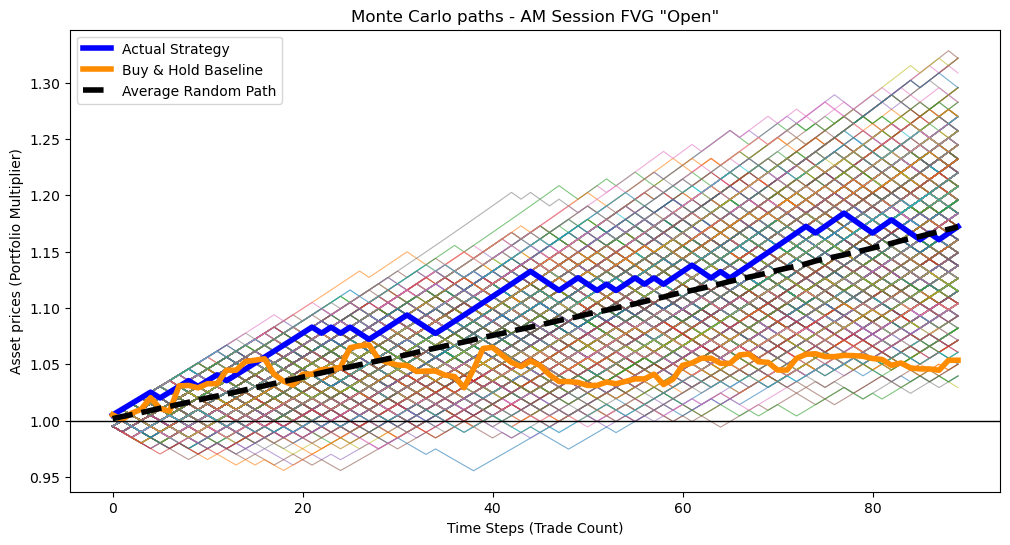

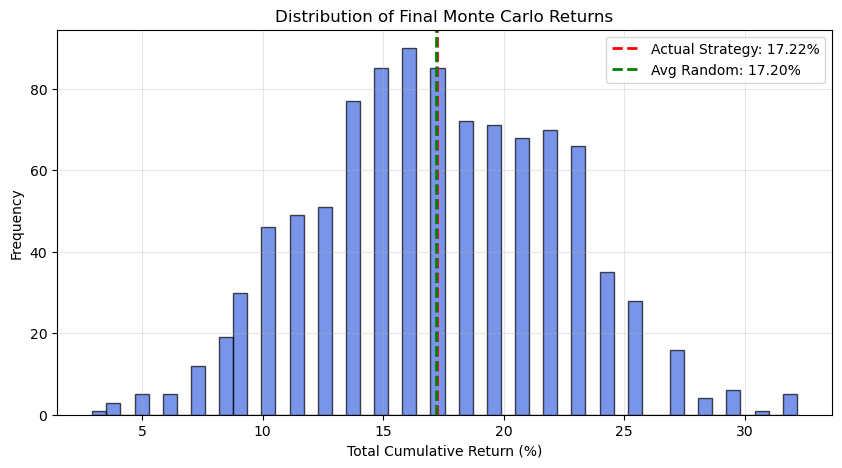

--- MONTE CARLO STATISTICS ---
Actual Strategy Return:   17.22%
Buy & Hold Baseline:      5.36%
Average Random Return:    17.20%
P-Value (Prob. of luck):  0.4420


In [14]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

# --- 1. PREPARE DATA ARRAYS ---
dates = data.index.date
highs = data['high'].values
lows = data['low'].values
times = data.index.time

take_profit_pct = 0.005
stop_loss_pct = 0.005

am_start = datetime.time(9, 30)
am_end = datetime.time(11, 0)

active_fvgs = []
strategy_returns_list = []
exit_times = []  

print("Running AM Session FVG 'Open' Sniper Strategy...")

# --- 2. EXECUTE THE AM/OPEN STRATEGY ---
for i in range(2, len(data)):
    current_date = dates[i]
    current_time = times[i]
    
    if current_date != dates[i-1]:
        active_fvgs = []
        
    c1_high = highs[i-2]
    c1_low = lows[i-2]
    c3_high = highs[i]
    c3_low = lows[i]
    
    # Bullish FVG
    if c1_high < c3_low:
        active_fvgs.append({'type': 'bull', 'open': c3_low, 'open_hit': False})
        
    # Bearish FVG
    elif c1_low > c3_high:
        active_fvgs.append({'type': 'bear', 'open': c3_high, 'open_hit': False})

    current_high = highs[i]
    current_low = lows[i]
    
    if am_start <= current_time <= am_end:
        for fvg in active_fvgs:
            # Bullish Entry
            if fvg['type'] == 'bull' and not fvg['open_hit'] and current_low <= fvg['open']:
                fvg['open_hit'] = True
                entry_price = fvg['open']
                
                for j in range(i, len(data)):
                    if dates[j] != current_date: 
                        break 
                    if highs[j] >= entry_price * (1 + take_profit_pct):
                        strategy_returns_list.append(take_profit_pct)
                        exit_times.append(data.index[j]) 
                        break
                    elif lows[j] <= entry_price * (1 - stop_loss_pct):
                        strategy_returns_list.append(-stop_loss_pct)
                        exit_times.append(data.index[j]) 
                        break

            # Bearish Entry
            elif fvg['type'] == 'bear' and not fvg['open_hit'] and current_high >= fvg['open']:
                fvg['open_hit'] = True
                entry_price = fvg['open']
                
                for j in range(i, len(data)):
                    if dates[j] != current_date: 
                        break 
                    if lows[j] <= entry_price * (1 - take_profit_pct):
                        strategy_returns_list.append(take_profit_pct)
                        exit_times.append(data.index[j]) 
                        break
                    elif highs[j] >= entry_price * (1 + stop_loss_pct):
                        strategy_returns_list.append(-stop_loss_pct)
                        exit_times.append(data.index[j]) 
                        break

if len(strategy_returns_list) == 0:
    print("No trades triggered under these strict conditions.")
else:
    # --- 3. APPLY TRUE GLOBAL BASELINE METHOD ---
    strategy_returns = pd.Series(strategy_returns_list, index=exit_times)
    strategy_returns = strategy_returns.sort_index()

    global_market_cumulative = (1 + data['market_return']).cumprod()
    baseline_path = global_market_cumulative.loc[strategy_returns.index].values

    # --- 4. MONTE CARLO SIMULATION ---
    num_simulations = 1000
    simulated_paths = np.zeros((len(strategy_returns), num_simulations))

    print(f"Running {num_simulations} Monte Carlo simulations. Please wait...\n")

    for i in range(num_simulations):
        random_returns = np.random.choice(strategy_returns.values, size=len(strategy_returns), replace=True)
        simulated_paths[:, i] = (1 + random_returns).cumprod()
        
    actual_path = (1 + strategy_returns.values).cumprod()
    
    # --- 5. VISUALISE ---
    average_path = np.mean(simulated_paths, axis=1)

    plt.figure(figsize=(12, 6))

    plt.plot(simulated_paths, alpha=0.6, linewidth=0.8)

    plt.plot(actual_path, color='blue', linewidth=4, label='Actual Strategy')
    plt.plot(baseline_path, color='darkorange', linewidth=4, label='Buy & Hold Baseline')
    plt.plot(average_path, color='black', linewidth=4, linestyle='--', label='Average Random Path')

    plt.axhline(1.0, color='black', linewidth=1)
    plt.title('Monte Carlo paths - AM Session FVG "Open"')
    plt.xlabel('Time Steps (Trade Count)')
    plt.ylabel('Asset prices (Portfolio Multiplier)')
    plt.legend(loc='upper left')

    plt.grid(False) 
    plt.show()

    final_sim_returns = (simulated_paths[-1, :] - 1) * 100
    actual_final_return = (actual_path[-1] - 1) * 100
    baseline_final_return = (baseline_path[-1] - 1) * 100

    paths_beating_actual = np.sum(final_sim_returns >= actual_final_return)
    p_value = paths_beating_actual / num_simulations

    plt.figure(figsize=(10, 5))
    plt.hist(final_sim_returns, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
    plt.axvline(actual_final_return, color='red', linestyle='dashed', linewidth=2, label=f'Actual Strategy: {actual_final_return:.2f}%')
    plt.axvline(np.mean(final_sim_returns), color='green', linestyle='dashed', linewidth=2, label=f'Avg Random: {np.mean(final_sim_returns):.2f}%')
    plt.title('Distribution of Final Monte Carlo Returns')
    plt.xlabel('Total Cumulative Return (%)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("--- MONTE CARLO STATISTICS ---")
    print(f"Actual Strategy Return:   {actual_final_return:.2f}%")
    print(f"Buy & Hold Baseline:      {baseline_final_return:.2f}%")
    print(f"Average Random Return:    {np.mean(final_sim_returns):.2f}%")
    print(f"P-Value (Prob. of luck):  {p_value:.4f}")

Running AM Session FVG 'Open' Sniper Strategy...
Running 1000 Monte Carlo simulations. Please wait...



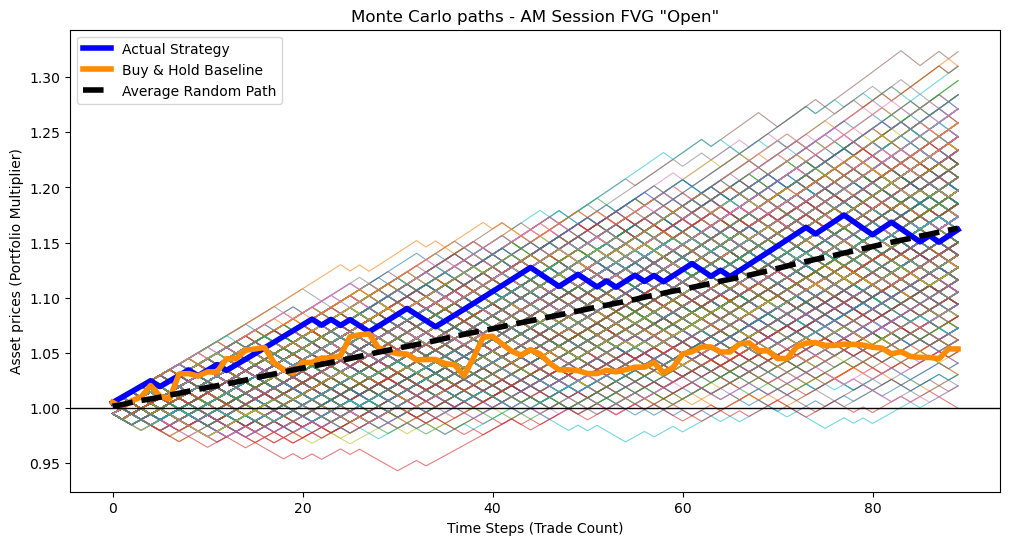

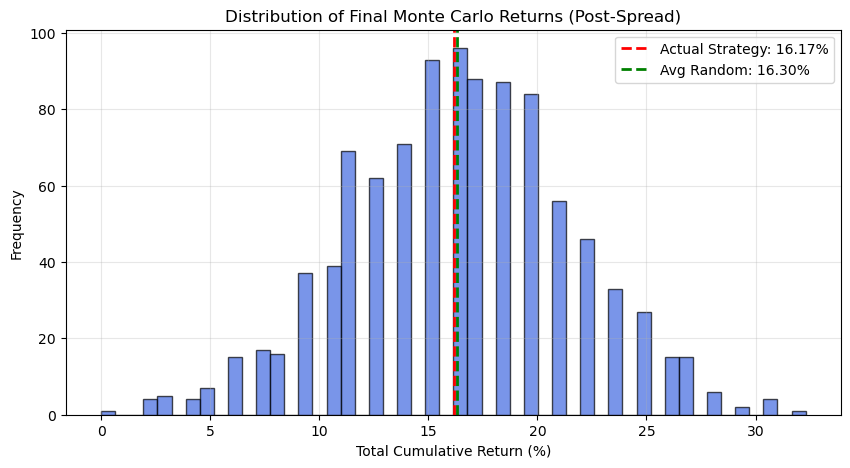

--- MONTE CARLO STATISTICS ---
Actual Strategy Return:   16.17%
Buy & Hold Baseline:      5.36%
Average Random Return:    16.30%
P-Value (Prob. of luck):  0.5580


In [15]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

# --- 1. PREPARE DATA ARRAYS ---
dates = data.index.date
highs = data['high'].values
lows = data['low'].values
times = data.index.time

take_profit_pct = 0.005
stop_loss_pct = 0.005

# NEW: Define spread / slippage cost per trade (0.01% = 0.0001)
spread_pct = 0.0001 

am_start = datetime.time(9, 30)
am_end = datetime.time(11, 0)

active_fvgs = []
strategy_returns_list = []
exit_times = []  

print("Running AM Session FVG 'Open' Sniper Strategy...")

# --- 2. EXECUTE THE AM/OPEN STRATEGY ---
for i in range(2, len(data)):
    current_date = dates[i]
    current_time = times[i]
    
    if current_date != dates[i-1]:
        active_fvgs = []
        
    c1_high = highs[i-2]
    c1_low = lows[i-2]
    c3_high = highs[i]
    c3_low = lows[i]
    
    # Bullish FVG
    if c1_high < c3_low:
        active_fvgs.append({'type': 'bull', 'open': c3_low, 'open_hit': False})
        
    # Bearish FVG
    elif c1_low > c3_high:
        active_fvgs.append({'type': 'bear', 'open': c3_high, 'open_hit': False})

    current_high = highs[i]
    current_low = lows[i]
    
    if am_start <= current_time <= am_end:
        for fvg in active_fvgs:
            # Bullish Entry
            if fvg['type'] == 'bull' and not fvg['open_hit'] and current_low <= fvg['open']:
                fvg['open_hit'] = True
                entry_price = fvg['open']
                
                for j in range(i, len(data)):
                    if dates[j] != current_date: 
                        break 
                    if highs[j] >= entry_price * (1 + take_profit_pct):
                        # Subtract spread from winning trade
                        strategy_returns_list.append(take_profit_pct - spread_pct)
                        exit_times.append(data.index[j]) 
                        break
                    elif lows[j] <= entry_price * (1 - stop_loss_pct):
                        # Subtract spread from losing trade (increases the loss)
                        strategy_returns_list.append(-stop_loss_pct - spread_pct)
                        exit_times.append(data.index[j]) 
                        break

            # Bearish Entry
            elif fvg['type'] == 'bear' and not fvg['open_hit'] and current_high >= fvg['open']:
                fvg['open_hit'] = True
                entry_price = fvg['open']
                
                for j in range(i, len(data)):
                    if dates[j] != current_date: 
                        break 
                    if lows[j] <= entry_price * (1 - take_profit_pct):
                        # Subtract spread from winning trade
                        strategy_returns_list.append(take_profit_pct - spread_pct)
                        exit_times.append(data.index[j]) 
                        break
                    elif highs[j] >= entry_price * (1 + stop_loss_pct):
                        # Subtract spread from losing trade (increases the loss)
                        strategy_returns_list.append(-stop_loss_pct - spread_pct)
                        exit_times.append(data.index[j]) 
                        break

if len(strategy_returns_list) == 0:
    print("No trades triggered under these strict conditions.")
else:
    # --- 3. APPLY TRUE GLOBAL BASELINE METHOD ---
    strategy_returns = pd.Series(strategy_returns_list, index=exit_times)
    strategy_returns = strategy_returns.sort_index()

    global_market_cumulative = (1 + data['market_return']).cumprod()
    baseline_path = global_market_cumulative.loc[strategy_returns.index].values

    # --- 4. MONTE CARLO SIMULATION ---
    num_simulations = 1000
    simulated_paths = np.zeros((len(strategy_returns), num_simulations))

    print(f"Running {num_simulations} Monte Carlo simulations. Please wait...\n")

    for i in range(num_simulations):
        random_returns = np.random.choice(strategy_returns.values, size=len(strategy_returns), replace=True)
        simulated_paths[:, i] = (1 + random_returns).cumprod()
        
    actual_path = (1 + strategy_returns.values).cumprod()
    
    # --- 5. VISUALISE ---
    average_path = np.mean(simulated_paths, axis=1)

    plt.figure(figsize=(12, 6))

    plt.plot(simulated_paths, alpha=0.6, linewidth=0.8)

    plt.plot(actual_path, color='blue', linewidth=4, label='Actual Strategy')
    plt.plot(baseline_path, color='darkorange', linewidth=4, label='Buy & Hold Baseline')
    plt.plot(average_path, color='black', linewidth=4, linestyle='--', label='Average Random Path')

    plt.axhline(1.0, color='black', linewidth=1)
    plt.title('Monte Carlo paths - AM Session FVG "Open"')
    plt.xlabel('Time Steps (Trade Count)')
    plt.ylabel('Asset prices (Portfolio Multiplier)')
    plt.legend(loc='upper left')

    plt.grid(False) 
    plt.show()

    final_sim_returns = (simulated_paths[-1, :] - 1) * 100
    actual_final_return = (actual_path[-1] - 1) * 100
    baseline_final_return = (baseline_path[-1] - 1) * 100

    paths_beating_actual = np.sum(final_sim_returns >= actual_final_return)
    p_value = paths_beating_actual / num_simulations

    plt.figure(figsize=(10, 5))
    plt.hist(final_sim_returns, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
    plt.axvline(actual_final_return, color='red', linestyle='dashed', linewidth=2, label=f'Actual Strategy: {actual_final_return:.2f}%')
    plt.axvline(np.mean(final_sim_returns), color='green', linestyle='dashed', linewidth=2, label=f'Avg Random: {np.mean(final_sim_returns):.2f}%')
    plt.title('Distribution of Final Monte Carlo Returns (Post-Spread)')
    plt.xlabel('Total Cumulative Return (%)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("--- MONTE CARLO STATISTICS ---")
    print(f"Actual Strategy Return:   {actual_final_return:.2f}%")
    print(f"Buy & Hold Baseline:      {baseline_final_return:.2f}%")
    print(f"Average Random Return:    {np.mean(final_sim_returns):.2f}%")
    print(f"P-Value (Prob. of luck):  {p_value:.4f}")